In [1]:
# Cell 1: Install and Import Required Libraries
!pip install tensorflow opencv-python tf-keras

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from zipfile import ZipFile
import matplotlib.pyplot as plt
import cv2
import string
import re

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Add, RepeatVector, Concatenate, Attention
from tensorflow.keras.layers import AdditiveAttention
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 840.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.9 MB/s eta 0:00:00


In [2]:
# Cell 2: Download Dataset
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d adityajn105/flickr8k

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
 95% 0.98G/1.04G [00:00<00:00, 1.18GB/s]
100% 1.04G/1.04G [00:00<00:00, 1.17GB/s]


In [3]:
# Cell 3: Unzip and Load Captions
with ZipFile("/content/flickr8k.zip", 'r') as zip_ref:
    zip_ref.extractall()

captions_path = '/content/captions.txt'
data = pd.read_csv(captions_path)
data.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [4]:
# Cell 4: Clean Captions
def clean_caption(caption):
    caption = caption.lower()
    caption = caption.translate(str.maketrans('', '', string.punctuation))
    caption = re.sub(r'\d+', '', caption)
    caption = re.sub(r'\s+', ' ', caption).strip()
    return caption

data['cleaned_caption'] = data['caption'].apply(clean_caption)
data['cleaned_caption'] = 'startseq ' + data['cleaned_caption'] + ' endseq'

In [15]:
# Cell 5: Load and Extract Image Features
xception_model = Xception(include_top=False, weights='imagenet', input_shape=(299, 299, 3))
xception_model.trainable = False

model_input = xception_model.input
model_output = tf.keras.layers.GlobalAveragePooling2D()(xception_model.output)
feature_extractor = Model(inputs=model_input, outputs=model_output)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tqdm import tqdm
import numpy as np
import os
import pickle
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input

image_folder = '/content/Images'
image_features = {}

# Step 1: Extract features for unique images only
unique_images = data['image'].unique()

for img_name in tqdm(unique_images, desc="Extracting features"):
    path = os.path.join(image_folder, img_name)
    if os.path.exists(path):
        img = load_img(path, target_size=(299, 299))
        img = img_to_array(img)
        img = preprocess_input(img)
        img = np.expand_dims(img, axis=0)
        feature = feature_extractor.predict(img, verbose=0)
        image_features[img_name] = feature.reshape(2048)
    else:
        print(f"⚠️ Missing file: {img_name}")

# Step 2: Align features with all captions (repeat features as needed)
all_image_features = np.array([
    image_features[img_name] for img_name in data['image']
])  # This matches shape with captions

print("Final shape of image features:", all_image_features.shape)



# Save image features to a pickle file
with open("image_features.pkl", "wb") as f:
    pickle.dump(image_features, f)

print("Image features saved to image_features.pkl")



Extracting features: 100%|██████████| 8091/8091 [1:47:45<00:00,  1.25it/s]


Final shape of image features: (40455, 2048)
Image features saved to image_features.pkl


In [16]:
import pickle

# Load the saved features
with open("image_features.pkl", "rb") as f:
    feature_dict = pickle.load(f)

print("✅ Image features loaded. Total images:", len(feature_dict))


✅ Image features loaded. Total images: 8091


In [17]:
# Cell 7: Prepare Data Mappings
captions_dict = {}
for idx, row in data.iterrows():
    img, caption = row['image'], row['cleaned_caption']
    captions_dict.setdefault(img, []).append(caption)

In [18]:
# Cell 8: Tokenizer and Max Length
tokenizer = Tokenizer()
tokenizer.fit_on_texts(data['cleaned_caption'])

vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in data['cleaned_caption'])
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("✅ Tokenizer saved as tokenizer.pkl")

✅ Tokenizer saved as tokenizer.pkl


In [19]:
# Cell 8: Train/Val Split
from sklearn.model_selection import train_test_split
train_data, val_data = train_test_split(data, test_size=0.15, random_state=42)

def build_caption_dict(df):
    cap_dict = {}
    for idx, row in df.iterrows():
        cap_dict.setdefault(row['image'], []).append(row['cleaned_caption'])
    return cap_dict

train_captions = build_caption_dict(train_data)
val_captions = build_caption_dict(val_data)

In [20]:
def data_generator(captions_dict, feature_dict, batch_size):
    X1, X2, y = [], [], []
    while True:
        for img_name, caps in captions_dict.items():
            img_feat = feature_dict[img_name if img_name.endswith('.jpg') else img_name + '.jpg']
            for cap in caps:
                seq = tokenizer.texts_to_sequences([cap])[0]
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    out_seq = tf.keras.utils.to_categorical([out_seq], num_classes=vocab_size)[0]
                    X1.append(img_feat)
                    X2.append(in_seq)
                    y.append(out_seq)
                    if len(X1) == batch_size:
                        yield (np.array(X1), np.array(X2)), np.array(y)
                        X1, X2, y = [], [], []

In [21]:
# Set max_length and vocab_size BEFORE model creation
all_sequences = [tokenizer.texts_to_sequences(caps) for caps in train_captions.values()]
flat_sequences = [seq for sublist in all_sequences for seq in sublist]

max_length = max(len(seq) for seq in flat_sequences)
vocab_size = len(tokenizer.word_index) + 1

# Image features input
inputs1 = Input(shape=(2048,))
fe1 = Dense(256, activation='relu')(inputs1)
fe1 = RepeatVector(max_length)(fe1)  # Repeat for each timestep

# Text input
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256)(inputs2)
se2 = LSTM(256, return_sequences=True)(se1)

# Attention mechanism
attn_layer = AdditiveAttention()([se2, fe1])  # context from image + text
decoder1 = Concatenate()([se2, attn_layer])
decoder2 = LSTM(256)(decoder1)

# Final output
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 35, 256)   │  2,247,936 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    524,544 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 35, 256)   │    525,312 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 35, 256)   │          0 │ dense_2[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ additive_attention… │ (None, 35, 256)   │        256 │ lstm_2[0][0],     │
│ (AdditiveAttention) │                   │            │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 35, 512)   │          0 │ lstm_2[0][0],     │
│ (Concatenate)       │                   │            │ additive_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 256)       │    787,456 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8781)      │  2,256,717 │ lstm_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,342,221 (24.19 MB)

 Trainable params: 6,342,221 (24.19 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 11: Train Model
batch_size = 64
train_steps = sum(len(v) for v in train_captions.values()) // batch_size
val_steps = sum(len(v) for v in val_captions.values()) // batch_size

def wrap_generator(captions_dict, feature_dict, batch_size):
    return tf.data.Dataset.from_generator(
        lambda: data_generator(captions_dict, feature_dict, batch_size),
        output_signature=(
            (
                tf.TensorSpec(shape=(None, 2048), dtype=tf.float32),
                tf.TensorSpec(shape=(None, max_length), dtype=tf.int32)
            ),
            tf.TensorSpec(shape=(None, vocab_size), dtype=tf.float32)
        )
    )


train_dataset = wrap_generator(train_captions, feature_dict, batch_size)
val_dataset = wrap_generator(val_captions, feature_dict, batch_size)


callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

model.fit(
    train_dataset,
    epochs=10,
    steps_per_epoch=train_steps,
    validation_data=val_dataset,
    validation_steps=val_steps,
    callbacks=callbacks
)

Epoch 1/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 6.0160

537/537 ━━━━━━━━━━━━━━━━━━━━ 998s 2s/step - loss: 6.0153 - val_loss: 5.0270
Epoch 2/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 5.0510

537/537 ━━━━━━━━━━━━━━━━━━━━ 995s 2s/step - loss: 5.0507 - val_loss: 4.5919
Epoch 3/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 4.6553

537/537 ━━━━━━━━━━━━━━━━━━━━ 996s 2s/step - loss: 4.6551 - val_loss: 4.3464
Epoch 4/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 4.4658

537/537 ━━━━━━━━━━━━━━━━━━━━ 995s 2s/step - loss: 4.4657 - val_loss: 4.1721
Epoch 5/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 4.2580

...

537/537 ━━━━━━━━━━━━━━━━━━━━ 995s 2s/step - loss: 4.1077 - val_loss: 3.8924
Epoch 7/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 3.9445

537/537 ━━━━━━━━━━━━━━━━━━━━ 995s 2s/step - loss: 3.9444 - val_loss: 3.7852
Epoch 8/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 3.8734

537/537 ━━━━━━━━━━━━━━━━━━━━ 995s 2s/step - loss: 3.8733 - val_loss: 3.6978
Epoch 9/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 3.7675

537/537 ━━━━━━━━━━━━━━━━━━━━ 995s 2s/step - loss: 3.7674 - val_loss: 3.6093
Epoch 10/10
537/537 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 3.7071

537/537 ━━━━━━━━━━━━━━━━━━━━ 996s 2s/step - loss: 3.7072 - val_loss: 3.5475


In [22]:
import tensorflow as tf
import pickle

# Load model
model = tf.keras.models.load_model("best_model.h5", custom_objects={'NotEqual': tf.keras.layers.Layer})

# Load tokenizer
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)


In [29]:
def generate_caption(feature, model, tokenizer, max_length=35, beam_index=3):
    start = [tokenizer.word_index['startseq']]
    sequences = [[start, 0.0]]

    while len(sequences[0][0]) < max_length:
        all_candidates = []
        for seq, score in sequences:
            sequence = pad_sequences([seq], maxlen=max_length)
            preds = model.predict([feature, sequence], verbose=0)[0]
            top_preds = np.argsort(preds)[-beam_index:]

            for word_idx in top_preds:
                new_seq = seq + [word_idx]
                new_score = score + np.log(preds[word_idx] + 1e-10)
                all_candidates.append([new_seq, new_score])

        # Sort by score and keep top beam_index sequences
        sequences = sorted(all_candidates, key=lambda tup: tup[1], reverse=True)[:beam_index]

        # Stop if all sequences have generated 'endseq'
        if all(tokenizer.index_word.get(seq[-1], '') == 'endseq' for seq, _ in sequences):
            break

    # Select best sequence
    best_seq = sequences[0][0]
    final_caption = [tokenizer.index_word.get(idx, '') for idx in best_seq]

    # Stop at first 'endseq'
    if 'endseq' in final_caption:
        final_caption = final_caption[:final_caption.index('endseq') + 1]

    return ' '.join(word for word in final_caption if word not in ['startseq', 'endseq'])


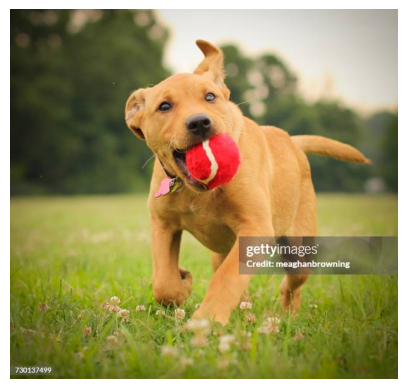

In [30]:
import cv2
from matplotlib import pyplot as plt

# Load image
img = cv2.imread('/content/Img 9.jpg')

# Convert from BGR (OpenCV default) to RGB (for correct colors)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show the image
plt.imshow(img_rgb)
plt.axis('off')  # Hide axis
plt.show()


In [37]:
# Cell 13: Test on New Image
test_img_path = '/content/Img 9.jpg'

if os.path.exists(test_img_path):
    img = load_img(test_img_path, target_size=(299, 299))
    img = img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    # Extract feature using the same feature_extractor used during training
    test_feature =feature_extractor.predict(img)

    # Generate and print caption
    caption = generate_caption(test_feature, model, tokenizer)

    print("Generated caption:", caption)
else:
    print(f"⚠️ File not found: {test_img_path}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 745ms/step
Generated caption: a black dog is running in the grass


In [38]:
!pip install nltk

In [39]:
# Download all necessary nltk data
import nltk
nltk.download('popular')  # includes punkt, wordnet, omw-1.4, etc.

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/names.zip.
[nltk_data]    | Downloading package shakespeare to /root/nltk_data...
[nlt

In [42]:
!pip install nltk rouge-score


  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=9ba6fce30b2e0d6982b3e9aec6e1bcfc46909f96f4bc60443ec05d9c8d914cf0
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score


In [43]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [50]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

def evaluate_caption_scores(reference, prediction):
    """
    Args:
        reference (list): List of reference sentences. (Can include multiple references)
        prediction (str): Predicted caption string.
    Returns:
        dict: BLEU, METEOR, and ROUGE scores.
    """
    smoothie = SmoothingFunction().method4

    # Ensure references are tokenized lists of words
    reference_tokens = [ref.split() for ref in reference]
    # Tokenize the prediction
    prediction_tokens = prediction.split()


    bleu1 = sentence_bleu(reference_tokens, prediction_tokens, weights=(1, 0, 0, 0), smoothing_function=smoothie)
    bleu2 = sentence_bleu(reference_tokens, prediction_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)

    # Pass tokenized reference list and tokenized prediction to meteor_score
    # The meteor_score function expects references to be a list of tokenized sentences
    meteor = meteor_score(reference_tokens, prediction_tokens) # Changed this line

    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    # ROUGE scorer also expects tokenized input, or it can handle strings
    # Sticking with the original implementation for ROUGE for consistency with user's code
    # Note: The ROUGE calculation currently only uses the first reference.
    rouge = scorer.score(reference[0], prediction)['rougeL'].fmeasure

    return {
        "BLEU-1": round(bleu1, 4),
        "BLEU-2": round(bleu2, 4),
        "METEOR": round(meteor, 4),
        "ROUGE-L": round(rouge, 4)
    }

# Ground truth captions (can have multiple references)
references = [
    "a brown dog is running through the grass with a red ball in mouth",
    "a brown dog runs through the grass with a red ball."
]

# Predicted caption
prediction = "a black dog is running in the grass"

# Calculate and print scores
scores = evaluate_caption_scores(references, prediction)
print("Evaluation Scores:", scores)

Evaluation Scores: {'BLEU-1': 0.6014, 'BLEU-2': 0.4209, 'METEOR': 0.4737, 'ROUGE-L': 0.5455}
